In [15]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [16]:
BASE_DIR = Path("/Users/tonytony/Final Project")
RAW_DIR = BASE_DIR / "Data" / "Raw"
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

PANEL_PATH = CLEAN_DIR / "panel_with_event_dummies_and_extra_drivers.csv"
GDP_PATH = RAW_DIR / "gdp.csv"
POP_PATH = RAW_DIR / "population.csv"
LIFE_PATH = RAW_DIR / "life_expectancy.csv"
META_PATH = RAW_DIR / "world_bank_country_metadata.csv"

COUNTRY_CODE_INPUT = "VNM"
TARGET_YEAR_INPUT = 2040

POP_FORECAST_MODEL = "LogHolt"
LIFE_FORECAST_MODEL = "Holt"   

print("Panel path:", PANEL_PATH)
print("GDP path:", GDP_PATH)
print("Population path:", POP_PATH)
print("Life path:", LIFE_PATH)
print("Metadata path:", META_PATH)
print("Country:", COUNTRY_CODE_INPUT)
print("Target year:", TARGET_YEAR_INPUT)

Panel path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
GDP path: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Population path: /Users/tonytony/Final Project/Data/Raw/population.csv
Life path: /Users/tonytony/Final Project/Data/Raw/life_expectancy.csv
Metadata path: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv
Country: VNM
Target year: 2040


In [17]:
# Cell 3 - Helper functions for World Bank raw data

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    return df


def to_long(df, value_name):
    year_cols = [col for col in df.columns if str(col).isdigit()]
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=value_name
    )
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    return long_df


def load_metadata():
    meta = pd.read_csv(META_PATH)

    meta = meta.rename(
        columns={
            "Country Code": "country_code",
            "World Bank Name": "country_name",
            "World Bank Region": "wb_region"
        }
    )

    meta = meta[["country_code", "country_name", "wb_region"]].copy()

    meta["country_code"] = meta["country_code"].astype(str).str.strip()
    meta["country_name"] = meta["country_name"].astype(str).str.strip()
    meta["wb_region"] = meta["wb_region"].astype(str).str.strip()

    # Bo aggregate rows de tranh lay khu vuc tong hop thay vi quoc gia
    meta = meta[meta["wb_region"].notna()].copy()
    meta = meta[meta["wb_region"] != ""].copy()
    meta = meta[meta["wb_region"].str.lower() != "aggregates"].copy()

    return meta


def add_region_info(long_df, value_col):
    meta = load_metadata()

    out = long_df.rename(
        columns={
            "Country Name": "country_name",
            "Country Code": "country_code"
        }
    ).copy()

    out["country_code"] = out["country_code"].astype(str).str.strip()
    out["country_name"] = out["country_name"].astype(str).str.strip()

    out = out.merge(meta, on="country_code", how="left", suffixes=("", "_meta"))

    # Neu ten quoc gia raw khong dep thi uu tien metadata
    if "country_name_meta" in out.columns:
        out["country_name"] = out["country_name_meta"].fillna(out["country_name"])
        out = out.drop(columns=["country_name_meta"], errors="ignore")

    out = out[["country_name", "country_code", "wb_region", "year", value_col]].copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    out = out.dropna(subset=["country_code", "year"])
    out["year"] = out["year"].astype(int)

    return out

In [18]:
gdp_long = add_region_info(
    to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"),
    "gdp_per_capita_usd"
)

pop_long = add_region_info(
    to_long(load_wdi(POP_PATH), "population_total"),
    "population_total"
)

life_long = add_region_info(
    to_long(load_wdi(LIFE_PATH), "life_expectancy_years"),
    "life_expectancy_years"
)

gdp_long = gdp_long[gdp_long["gdp_per_capita_usd"].notna()].copy()
pop_long = pop_long[pop_long["population_total"].notna()].copy()
life_long = life_long[life_long["life_expectancy_years"].notna()].copy()

print("GDP long shape:", gdp_long.shape)
print("Population long shape:", pop_long.shape)
print("Life long shape:", life_long.shape)

display(gdp_long.head())
display(pop_long.head())
display(life_long.head())

GDP long shape: (14561, 5)
Population long shape: (17195, 5)
Life long shape: (16926, 5)


,country_name,country_code,wb_region,year,gdp_per_capita_usd
1,Africa Eastern and Southern,AFE,NaN,1960,186.0892
3,Africa Western and Central,AFW,NaN,1960,121.9368
9,Argentina,ARG,Latin America & Caribbean,1960,778.2517
13,Australia,AUS,East Asia & Pacific,1960,"1,813.4311"
14,Austria,AUT,Europe & Central Asia,1960,939.9148


,country_name,country_code,wb_region,year,population_total
0,Aruba,ABW,Latin America & Caribbean,1960,"54,922.0000"
1,Africa Eastern and Southern,AFE,NaN,1960,"130,075,728.0000"
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1960,"9,035,043.0000"
3,Africa Western and Central,AFW,NaN,1960,"97,630,925.0000"
4,Angola,AGO,Sub-Saharan Africa,1960,"5,231,654.0000"


,country_name,country_code,wb_region,year,life_expectancy_years
0,Aruba,ABW,Latin America & Caribbean,1960,64.0490
1,Africa Eastern and Southern,AFE,NaN,1960,44.1697
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",1960,32.7990
3,Africa Western and Central,AFW,NaN,1960,37.7796
4,Angola,AGO,Sub-Saharan Africa,1960,37.9330


In [19]:
# Cell 5 - Load panel data for XGBoost Model 1

model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "target_log_gdp_next_year"
]

panel_df = pd.read_csv(PANEL_PATH, usecols=model_cols)

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "target_log_gdp_next_year"
]

for col in numeric_cols:
    panel_df[col] = pd.to_numeric(panel_df[col], errors="coerce")

panel_df["country_name"] = panel_df["country_name"].astype(str)
panel_df["country_code"] = panel_df["country_code"].astype(str)
panel_df["wb_region"] = panel_df["wb_region"].astype(str)

model_df = panel_df.dropna().copy()
model_df["year"] = model_df["year"].astype(int)

print("Model 1 panel shape:", model_df.shape)
print("Feature year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))
print("Target year range:", int((model_df["year"] + 1).min()), "-", int((model_df["year"] + 1).max()))
display(model_df.head())

Model 1 panel shape: (11159, 10)
Feature year range: 1960 - 2022
Target year range: 1961 - 2023


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year
0,Aruba,ABW,Latin America & Caribbean,1986,"6,767.5592",71.8310,"59,931.0000",8.8199,11.0009,9.0172
1,Aruba,ABW,Latin America & Caribbean,1987,"8,244.0457",72.4480,"59,159.0000",9.0172,10.9880,9.2160
2,Aruba,ABW,Latin America & Caribbean,1988,"10,056.2614",72.5190,"59,331.0000",9.2160,10.9909,9.3507
3,Aruba,ABW,Latin America & Caribbean,1989,"11,507.2172",72.5310,"60,443.0000",9.3507,11.0095,9.4082
4,Aruba,ABW,Latin America & Caribbean,1990,"12,187.5364",72.5460,"62,753.0000",9.4082,11.0470,9.4905


In [20]:

feature_cols = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years"
]

target_col = "target_log_gdp_next_year"

# Dung 2016-2017 lam validation de chon so boosting rounds
train_core_df = model_df[model_df["year"] < 2016].copy()
valid_df = model_df[(model_df["year"] >= 2016) & (model_df["year"] <= 2017)].copy()

print("Train core rows:", train_core_df.shape[0])
print("Validation rows:", valid_df.shape[0])

dtrain_core = xgb.DMatrix(train_core_df[feature_cols], label=train_core_df[target_col], feature_names=feature_cols)
dvalid = xgb.DMatrix(valid_df[feature_cols], label=valid_df[target_col], feature_names=feature_cols)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 4,
    "eta": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 5,
    "seed": 42
}

evals_result = {}

tuned_model = xgb.train(
    params=params,
    dtrain=dtrain_core,
    num_boost_round=800,
    evals=[(dtrain_core, "train"), (dvalid, "valid")],
    early_stopping_rounds=40,
    evals_result=evals_result,
    verbose_eval=False
)

best_nrounds = tuned_model.best_iteration + 1
print("Best boosting rounds:", best_nrounds)

# Refit tren toan bo du lieu co label de forecast tuong lai
dfit_full = xgb.DMatrix(model_df[feature_cols], label=model_df[target_col], feature_names=feature_cols)

final_model_1 = xgb.train(
    params=params,
    dtrain=dfit_full,
    num_boost_round=best_nrounds,
    evals=[(dfit_full, "fit_full")],
    verbose_eval=False
)

print("Final Model 1 trained on full labeled history.")

Train core rows: 9695
Validation rows: 422
Best boosting rounds: 529
Final Model 1 trained on full labeled history.


In [25]:
# Cell 7 - Helper functions for future feature paths

def forecast_country_series(series, model_name, forecast_horizon):
    series = pd.Series(series).dropna().astype(float)
    series = series[~series.index.duplicated(keep="last")]

    if forecast_horizon <= 0:
        return np.array([])

    if len(series) < 3:
        last_val = float(series.iloc[-1])
        return np.repeat(last_val, forecast_horizon)

    if model_name == "Naive":
        last_val = float(series.iloc[-1])
        return np.repeat(last_val, forecast_horizon)

    if model_name == "Holt":
        fitted = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)
        fc = fitted.forecast(forecast_horizon)
        return np.asarray(fc, dtype=float)

    if model_name == "LogHolt":
        safe_series = series.clip(lower=1)
        log_series = np.log(safe_series)

        fitted = ExponentialSmoothing(
            log_series,
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)

        fc = fitted.forecast(forecast_horizon)
        return np.exp(np.asarray(fc, dtype=float))

    raise ValueError(f"Unsupported model_name: {model_name}")


def build_actual_lookup(long_df, country_code, value_col):
    country_df = long_df[long_df["country_code"] == country_code].copy().sort_values("year")

    if country_df.empty:
        raise ValueError(f"No data found for country_code={country_code} in {value_col}")

    country_df[value_col] = pd.to_numeric(country_df[value_col], errors="coerce")
    country_df = country_df[country_df[value_col].notna()].copy()

    actual_lookup = dict(zip(country_df["year"], country_df[value_col]))
    last_actual_year = int(country_df["year"].max())

    return actual_lookup, last_actual_year, country_df


def build_forecast_lookup(long_df, country_code, value_col, forecast_to_year, model_name):
    country_df = long_df[long_df["country_code"] == country_code].copy().sort_values("year")

    if country_df.empty:
        raise ValueError(f"No data found for country_code={country_code} in {value_col}")

    country_df[value_col] = pd.to_numeric(country_df[value_col], errors="coerce")
    country_df = country_df[country_df[value_col].notna()].copy()

    actual_lookup = dict(zip(country_df["year"], country_df[value_col]))
    last_actual_year = int(country_df["year"].max())

    if forecast_to_year <= last_actual_year:
        return actual_lookup, last_actual_year, country_df

    horizon = forecast_to_year - last_actual_year
    series = country_df.set_index("year")[value_col]

    future_values = forecast_country_series(
        series=series,
        model_name=model_name,
        forecast_horizon=horizon
    )

    future_lookup = {
        year: value
        for year, value in zip(range(last_actual_year + 1, forecast_to_year + 1), future_values)
    }

    full_lookup = {**actual_lookup, **future_lookup}
    return full_lookup, last_actual_year, country_df

In [26]:
# Cell 8 - Inspect selected country and build future feature paths

country_code_input = COUNTRY_CODE_INPUT.upper()

# GDP chi lay ACTUAL history
gdp_lookup, gdp_last_year, gdp_country_df = build_actual_lookup(
    gdp_long,
    country_code=country_code_input,
    value_col="gdp_per_capita_usd"
)

# Population va Life moi duoc forecast den nam feature cuoi cung = target_year - 1
pop_lookup, pop_last_year, pop_country_df = build_forecast_lookup(
    pop_long,
    country_code=country_code_input,
    value_col="population_total",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=POP_FORECAST_MODEL
)

life_lookup, life_last_year, life_country_df = build_forecast_lookup(
    life_long,
    country_code=country_code_input,
    value_col="life_expectancy_years",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=LIFE_FORECAST_MODEL
)

country_name_value = gdp_country_df["country_name"].dropna().iloc[-1]
region_value = gdp_country_df["wb_region"].dropna().iloc[-1] if gdp_country_df["wb_region"].notna().any() else "Unknown"

print("Country:", country_name_value, f"({country_code_input})")
print("Region:", region_value)
print("Latest actual GDP year:", gdp_last_year)
print("Latest actual Population year:", pop_last_year)
print("Latest actual Life year:", life_last_year)
print("Target forecast year:", TARGET_YEAR_INPUT)

print("GDP lookup years:", min(gdp_lookup.keys()), "-", max(gdp_lookup.keys()))
print("Population lookup years:", min(pop_lookup.keys()), "-", max(pop_lookup.keys()))
print("Life lookup years:", min(life_lookup.keys()), "-", max(life_lookup.keys()))

Country: Viet Nam (VNM)
Region: East Asia & Pacific
Latest actual GDP year: 2024
Latest actual Population year: 2024
Latest actual Life year: 2023
Target forecast year: 2040
GDP lookup years: 1985 - 2024
Population lookup years: 1960 - 2039
Life lookup years: 1960 - 2039


In [27]:
# Cell 9 - Recursive GDP forecast using XGBoost Model 1

def recursive_gdp_forecast_model_1(
    booster,
    country_code,
    country_name,
    region_name,
    target_year,
    gdp_lookup,
    pop_lookup,
    life_lookup
):
    actual_gdp_years = sorted(gdp_lookup.keys())
    latest_actual_gdp_year = max(actual_gdp_years)

    if target_year <= latest_actual_gdp_year:
        raise ValueError(
            f"Target year must be greater than the latest actual GDP year. "
            f"Latest actual GDP year for {country_code} is {latest_actual_gdp_year}, "
            f"but you entered {target_year}."
        )

    current_gdp = float(gdp_lookup[latest_actual_gdp_year])

    forecast_rows = []

    for forecast_year in range(latest_actual_gdp_year + 1, target_year + 1):
        feature_year = forecast_year - 1

        if feature_year not in pop_lookup:
            raise ValueError(f"Missing population value for feature year {feature_year}")

        if feature_year not in life_lookup:
            raise ValueError(f"Missing life expectancy value for feature year {feature_year}")

        pop_value = float(pop_lookup[feature_year])
        life_value = float(life_lookup[feature_year])

        feature_frame = pd.DataFrame(
            {
                "log_gdp_per_capita": [np.log(max(current_gdp, 1e-9))],
                "log_population_total": [np.log(max(pop_value, 1e-9))],
                "life_expectancy_years": [life_value],
            }
        )

        dmatrix = xgb.DMatrix(feature_frame[feature_cols], feature_names=feature_cols)
        pred_log_gdp = float(booster.predict(dmatrix)[0])
        pred_gdp = float(np.exp(pred_log_gdp))

        forecast_rows.append(
            {
                "country_name": country_name,
                "country_code": country_code,
                "wb_region": region_name,
                "latest_actual_gdp_year": latest_actual_gdp_year,
                "feature_year_used": feature_year,
                "target_year": forecast_year,
                "gdp_input_used": current_gdp,
                "population_used": pop_value,
                "life_expectancy_used": life_value,
                "predicted_log_gdp_per_capita": pred_log_gdp,
                "predicted_gdp_per_capita_usd": pred_gdp,
                "population_model": POP_FORECAST_MODEL,
                "life_model": LIFE_FORECAST_MODEL,
                "gdp_model": "XGBoost Model 1 Recursive"
            }
        )

        current_gdp = pred_gdp

    return pd.DataFrame(forecast_rows)

In [28]:
# Cell 10 - Run forecast

forecast_model_1_df = recursive_gdp_forecast_model_1(
    booster=final_model_1,
    country_code=country_code_input,
    country_name=country_name_value,
    region_name=region_value,
    target_year=TARGET_YEAR_INPUT,
    gdp_lookup=gdp_lookup,
    pop_lookup=pop_lookup,
    life_lookup=life_lookup
)

display(forecast_model_1_df.head(10))
display(forecast_model_1_df.tail(10))

,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,gdp_model
0,Viet Nam,VNM,East Asia & Pacific,2024,2024,2025,"4,717.2903","100,987,686.0000",74.8784,8.5280,"5,054.1336",LogHolt,Holt,XGBoost Model 1 Recursive
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,2026,"5,054.1336","101,627,204.3534",75.1413,8.5869,"5,361.2283",LogHolt,Holt,XGBoost Model 1 Recursive
2,Viet Nam,VNM,East Asia & Pacific,2024,2026,2027,"5,361.2283","102,270,772.5438",75.4042,8.6487,"5,702.8956",LogHolt,Holt,XGBoost Model 1 Recursive
3,Viet Nam,VNM,East Asia & Pacific,2024,2027,2028,"5,702.8956","102,918,416.2179",75.6671,8.6959,"5,978.4474",LogHolt,Holt,XGBoost Model 1 Recursive
4,Viet Nam,VNM,East Asia & Pacific,2024,2028,2029,"5,978.4474","103,570,161.1842",75.9300,8.7440,"6,273.1973",LogHolt,Holt,XGBoost Model 1 Recursive
5,Viet Nam,VNM,East Asia & Pacific,2024,2029,2030,"6,273.1973","104,226,033.4148",76.1929,8.8012,"6,641.9813",LogHolt,Holt,XGBoost Model 1 Recursive
6,Viet Nam,VNM,East Asia & Pacific,2024,2030,2031,"6,641.9813","104,886,059.0461",76.4558,8.8891,"7,252.7593",LogHolt,Holt,XGBoost Model 1 Recursive
7,Viet Nam,VNM,East Asia & Pacific,2024,2031,2032,"7,252.7593","105,550,264.3802",76.7187,8.9307,"7,560.2698",LogHolt,Holt,XGBoost Model 1 Recursive
8,Viet Nam,VNM,East Asia & Pacific,2024,2032,2033,"7,560.2698","106,218,675.8855",76.9816,9.0296,"8,346.5374",LogHolt,Holt,XGBoost Model 1 Recursive
9,Viet Nam,VNM,East Asia & Pacific,2024,2033,2034,"8,346.5374","106,891,320.1982",77.2445,9.1474,"9,390.2265",LogHolt,Holt,XGBoost Model 1 Recursive


,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,gdp_model
6,Viet Nam,VNM,East Asia & Pacific,2024,2030,2031,"6,641.9813","104,886,059.0461",76.4558,8.8891,"7,252.7593",LogHolt,Holt,XGBoost Model 1 Recursive
7,Viet Nam,VNM,East Asia & Pacific,2024,2031,2032,"7,252.7593","105,550,264.3802",76.7187,8.9307,"7,560.2698",LogHolt,Holt,XGBoost Model 1 Recursive
8,Viet Nam,VNM,East Asia & Pacific,2024,2032,2033,"7,560.2698","106,218,675.8855",76.9816,9.0296,"8,346.5374",LogHolt,Holt,XGBoost Model 1 Recursive
9,Viet Nam,VNM,East Asia & Pacific,2024,2033,2034,"8,346.5374","106,891,320.1982",77.2445,9.1474,"9,390.2265",LogHolt,Holt,XGBoost Model 1 Recursive
10,Viet Nam,VNM,East Asia & Pacific,2024,2034,2035,"9,390.2265","107,568,224.1231",77.5074,9.2340,"10,239.6441",LogHolt,Holt,XGBoost Model 1 Recursive
11,Viet Nam,VNM,East Asia & Pacific,2024,2035,2036,"10,239.6441","108,249,414.6348",77.7703,9.2713,"10,629.0195",LogHolt,Holt,XGBoost Model 1 Recursive
12,Viet Nam,VNM,East Asia & Pacific,2024,2036,2037,"10,629.0195","108,934,918.8788",78.0332,9.3500,"11,498.6743",LogHolt,Holt,XGBoost Model 1 Recursive
13,Viet Nam,VNM,East Asia & Pacific,2024,2037,2038,"11,498.6743","109,624,764.1722",78.2961,9.4150,"12,270.6281",LogHolt,Holt,XGBoost Model 1 Recursive
14,Viet Nam,VNM,East Asia & Pacific,2024,2038,2039,"12,270.6281","110,318,978.0055",78.5590,9.5160,"13,574.6292",LogHolt,Holt,XGBoost Model 1 Recursive
15,Viet Nam,VNM,East Asia & Pacific,2024,2039,2040,"13,574.6292","111,017,588.0429",78.8219,9.6458,"15,456.6687",LogHolt,Holt,XGBoost Model 1 Recursive


In [29]:
# Cell 11 - Cleaner output table

output_df = forecast_model_1_df[
    [
        "target_year",
        "population_used",
        "life_expectancy_used",
        "predicted_gdp_per_capita_usd"
    ]
].copy()

output_df["population_used"] = output_df["population_used"].round(0).astype("int64")
output_df["life_expectancy_used"] = output_df["life_expectancy_used"].round(2)
output_df["predicted_gdp_per_capita_usd"] = output_df["predicted_gdp_per_capita_usd"].round(2)

display(output_df)

,target_year,population_used,life_expectancy_used,predicted_gdp_per_capita_usd
0,2025,100987686,74.8800,"5,054.1300"
1,2026,101627204,75.1400,"5,361.2300"
2,2027,102270773,75.4000,"5,702.9000"
3,2028,102918416,75.6700,"5,978.4500"
4,2029,103570161,75.9300,"6,273.2000"
5,2030,104226033,76.1900,"6,641.9800"
6,2031,104886059,76.4600,"7,252.7600"
7,2032,105550264,76.7200,"7,560.2700"
8,2033,106218676,76.9800,"8,346.5400"
9,2034,106891320,77.2400,"9,390.2300"


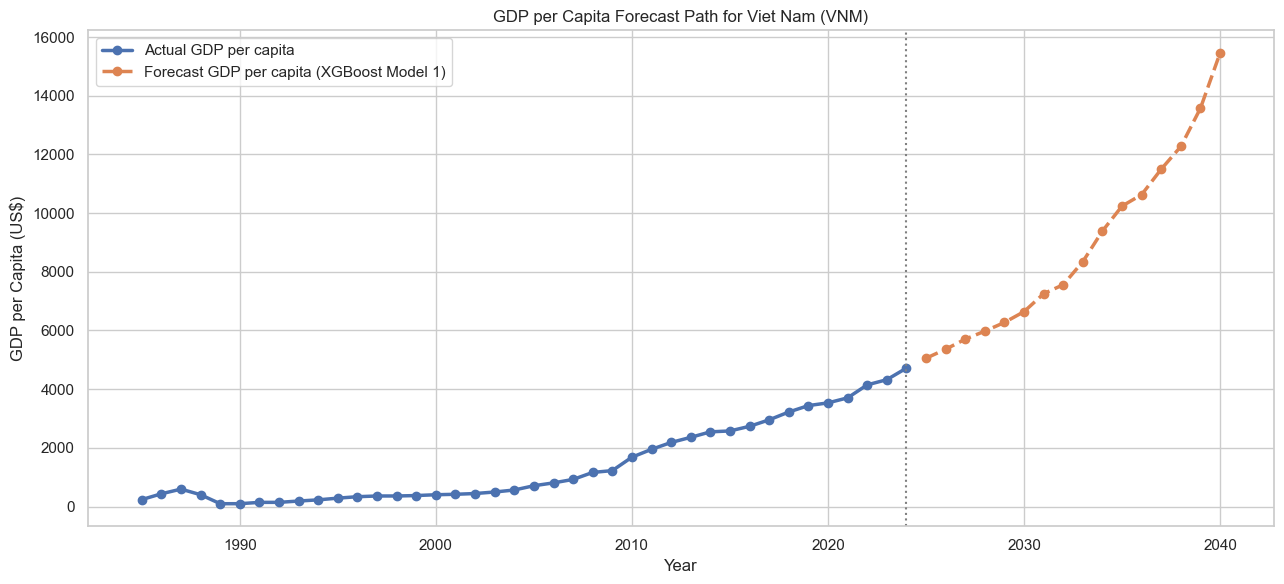

In [30]:
# Cell 12 - Plot forecast path

historical_plot_df = gdp_country_df[["year", "gdp_per_capita_usd"]].copy()
historical_plot_df = historical_plot_df.rename(columns={"year": "target_year"})
historical_plot_df["series_type"] = "Actual GDP per capita"

future_plot_df = forecast_model_1_df[["target_year", "predicted_gdp_per_capita_usd"]].copy()
future_plot_df = future_plot_df.rename(columns={"predicted_gdp_per_capita_usd": "gdp_per_capita_usd"})
future_plot_df["series_type"] = "Forecast GDP per capita"

plot_df = pd.concat([historical_plot_df, future_plot_df], ignore_index=True)

plt.figure(figsize=(13, 6))

actual_df = plot_df[plot_df["series_type"] == "Actual GDP per capita"]
forecast_df = plot_df[plot_df["series_type"] == "Forecast GDP per capita"]

plt.plot(
    actual_df["target_year"],
    actual_df["gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    label="Actual GDP per capita"
)

plt.plot(
    forecast_df["target_year"],
    forecast_df["gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Forecast GDP per capita (XGBoost Model 1)"
)

plt.axvline(x=int(actual_df["target_year"].max()), color="gray", linestyle=":", linewidth=1.5)
plt.title(f"GDP per Capita Forecast Path for {country_name_value} ({country_code_input})")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Cell 13 - Save output

save_path = CLEAN_DIR / f"gdp_xgboost_model_1_future_forecast_{country_code_input}_{TARGET_YEAR_INPUT}.csv"
forecast_model_1_df.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_1_future_forecast_VNM_2040.csv


In [32]:
# Cell 14 - Quick summary for presentation

latest_forecast_row = forecast_model_1_df.iloc[-1]

print("=== MODEL 1 FUTURE FORECAST SUMMARY ===")
print("Country:", latest_forecast_row["country_name"], f"({latest_forecast_row['country_code']})")
print("Region:", latest_forecast_row["wb_region"])
print("Target year:", int(latest_forecast_row["target_year"]))
print("Predicted GDP per capita (US$):", round(float(latest_forecast_row["predicted_gdp_per_capita_usd"]), 2))
print("Population model used:", latest_forecast_row["population_model"])
print("Life expectancy model used:", latest_forecast_row["life_model"])
print("GDP model used:", latest_forecast_row["gdp_model"])

=== MODEL 1 FUTURE FORECAST SUMMARY ===
Country: Viet Nam (VNM)
Region: East Asia & Pacific
Target year: 2040
Predicted GDP per capita (US$): 15456.67
Population model used: LogHolt
Life expectancy model used: Holt
GDP model used: XGBoost Model 1 Recursive
